In [1]:
import sys
from pathlib import Path
import importlib

# Add library folder to Python path
project_root = Path.cwd().parent
library_path = project_root / "library"

if str(library_path) not in sys.path:
    sys.path.append(str(library_path))

import lib_get_signal_from_airyscan as airyscan
importlib.reload(airyscan)

import os
import math

import numpy as np
import pandas as pd
import xarray as xr

# Image I/O
import napari
from aicsimageio import AICSImage
from skimage import io, measure
from skimage.measure import regionprops_table
import tifffile as tf
import tifftools
import czifile
from czifile import CziFile
from PIL import Image
import imageio

# Plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# for the "reorder" section
import re

from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
from matplotlib.patches import Patch
from typing import Dict, Iterable

# for downloading as png/svg
import imageio.v3 as iio
from napari.utils.colormaps import Colormap
from matplotlib.colors import LinearSegmentedColormap


/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.error_wrappers:ValidationError` has been moved to `pydantic:ValidationError`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
# Add config folder to path. This is where we store paths to the raw images, manually defined label masks, and z-ranges.
config_path = project_root / "configs"

if str(config_path) not in sys.path:
    sys.path.append(str(config_path))

import airyscan_config as config
importlib.reload(config)

images = config.images
label_masks = config.label_masks
label_masks_checking = config.label_masks_checking
z_ranges_by_fly = config.z_ranges_by_fly

# try the colors

In [3]:
def preview_color(rgb):
    rgb = np.asarray(rgb, dtype=float)

    fig, ax = plt.subplots(figsize=(2, 2))
    ax.imshow([[rgb]])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

In [4]:
def preview_napari_colors(*colormaps):
    """
    Preview the endpoint color of one or more Napari Colormaps.

    Parameters
    ----------
    *colormaps : napari.utils.colormaps.Colormap
        One or more Napari Colormap objects.
    """

    n = len(colormaps)
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))

    if n == 1:
        axes = [axes]

    for ax, cmap in zip(axes, colormaps):

        # last color = maximum intensity color
        rgb = cmap.colors[-1][:3]

        ax.imshow([[rgb]])
        ax.set_title(cmap.name, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

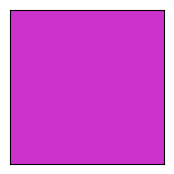

In [27]:
preview_color((0.8, 0.2, 0.8))

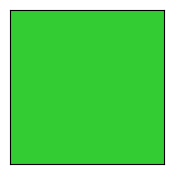

In [26]:
preview_color((0.2, 0.8, 0.2))

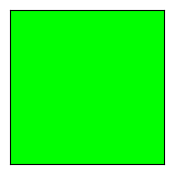

In [28]:
preview_color((0, 1, 0))

In [7]:
my_tdt = Colormap(
    colors=[
        [0, 0, 0, 1],          # black for zero intensity
        [0.8, 0.2, 0.8, 1],
    ],
    name="my_tdt",
)

my_glucl = Colormap(
    colors=[
        [0, 0, 0, 1],          # black for zero intensity
        [0.2, 0.8, 0.2, 1],
    ],
    name="my_glucl",
)

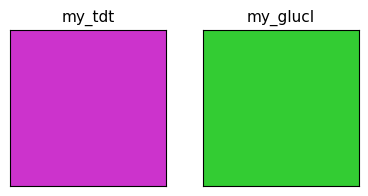

In [32]:
preview_napari_colors(my_tdt, my_glucl)

In [14]:
my_tdt_blackandwhite = Colormap(
    colors=[
        [1, 1, 1, 1],          # white for zero intensity
        [0, 0, 0, 1],
    ],
    name="my_tdt_blackandwhite",
)

# load the fly

method 1: load fly from the analyzed dataset

In [6]:
current_fly = "fly8"   # <-- switch here

In [7]:
assets_image = airyscan.load_fly(
    current_fly,
    images=images,
    red_idx=1,
    green_idx=2,
    blue_idx=0,)
red_channel = assets_image["red_channel"]
green_channel = assets_image["green_channel"]
blue_channel = assets_image["blue_channel"]

method 2: load from unanalyzed dataset

In [5]:
current_fly = "/Users/fisherguest/Documents/sansa images/09062025/SC-0906-fly10.czi"   # <-- switch here

In [6]:
# import image:
img = AICSImage(current_fly)

# Get the data in (C, Z, Y, X)
# C: Channels (e.g., the different lasers/fluorophores); Z: Z-stacks (slices in depth); Y and X: The spatial dimensions (height and width)
# i don't have S or T.
data = img.get_image_data("CZYX", S=0, T=0)

# checked using "previous TQ method": 568 is first (now second) channel, 488 is second (now third) channel.
red_channel   = data[1]
green_channel = data[2]
#blue_channel = data[0]

# open the czi in napari

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


(-0.5, 8207.5, 7719.5, -0.5)

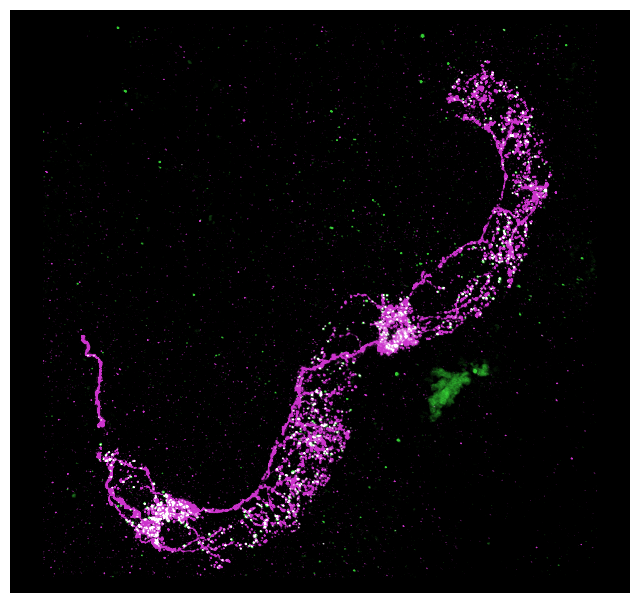

In [8]:
with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name='568 Channel',
        colormap=my_tdt,
        blending='additive',
        contrast_limits=(500, 3500),
        rendering='mip',
        #attenuation=0.05,
    )
    viewer.add_image(
        green_channel,
        name='488 Channel',
        colormap=my_glucl,
        blending='additive',
        contrast_limits=(500, 3000),
        rendering='mip',
    )

    # 2) Grab a *4× larger* screenshot of just the 3D canvas:
    highres = viewer.screenshot(canvas_only=True, scale=4)

# 3) Embed in a Matplotlib fig and save:
fig, ax = plt.subplots(figsize=(8, 8))   # size in inches is arbitrary
ax.imshow(highres, interpolation='nearest')
ax.axis('off')

# save the images

In [9]:
# both channels

with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name='568 Channel',
        colormap=my_tdt,
        blending='additive',
        contrast_limits=(500, 3500),
        rendering='mip',
        #attenuation=0.05,
    )
    viewer.add_image(
        green_channel,
        name='488 Channel',
        colormap=my_glucl,
        blending='additive',
        contrast_limits=(500, 3000),
        rendering='mip',
    )

    # 2) Grab a *4× larger* screenshot of just the 3D canvas:
    highres = viewer.screenshot(canvas_only=True, scale=4)

# 3) Embed in a Matplotlib fig and save:
fig, ax = plt.subplots(figsize=(8, 8))   # size in inches is arbitrary
ax.imshow(highres, interpolation='nearest')
ax.axis('off')

# choose output folder
output_dir = project_root / "results" / "images"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / f"fly10_2channels.png",
    format="png",
    bbox_inches="tight",
    pad_inches=0,
    dpi=800,
)
plt.close(fig)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


In [15]:
# tdt channel

with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name="568 Channel",
        colormap=my_tdt_blackandwhite,
        blending="additive",
        contrast_limits=(500, 3500),
        rendering="mip",
    )

    highres = viewer.screenshot(canvas_only=True, scale=4)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(highres, interpolation="nearest")
ax.axis("off")


output_dir = project_root / "results" / "images"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / "fly10_568channel_blackandwhite.png",
    format="png",
    bbox_inches="tight",
    pad_inches=0,
    dpi=800,
)
plt.close(fig)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


In [11]:
# GluCl channel

with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        green_channel,
        name="488 Channel",
        colormap=my_glucl,
        blending="additive",
        contrast_limits=(500, 3000),
        rendering="mip",
    )

    highres = viewer.screenshot(canvas_only=True, scale=4)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(highres, interpolation="nearest")
ax.axis("off")

output_dir = project_root / "results" / "images"
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / "fly10_488channel.png",
    format="png",
    bbox_inches="tight",
    pad_inches=0,
    dpi=800,
)
plt.close(fig)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


some notes:
fly10:
- tdt
contrast_limits=(600, 2500),
- gfp
contrast_limits=(700, 4500),

fly6:
- tdt
contrast_limits=(500, 4500), (blue: (500, 3500))
- gfp
contrast_limits=(500, 3000),


saved good combination:

customized_1: tdt: (0, 0.1, 0.6). glucl: (1, 0.9, 0.4) --- blue membrane too dark

customized_2: tdt: (0, 0.5, 0.8). glucl: (1, 0.5, 0.2) --- orange dots too dark

customized_2: tdt: (0, 0.3, 0.8). glucl: (1, 0.7, 0.2) --- orange dots still too dark

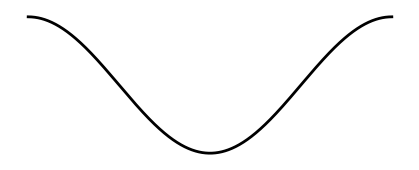

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# One period (T = 1)
x = np.linspace(0, 1, 1000)
y = np.cos(2 * np.pi * x)

fig, ax = plt.subplots(figsize=(4, 1.5))

ax.plot(x, y, color="black", linewidth=2)

# Remove everything except the curve
ax.axis("off")

# Remove all margins
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save as editable vector
plt.savefig("cosine.svg", transparent=True, bbox_inches="tight", pad_inches=0)

plt.show()